# OTF Scan --- Diagnostics & Manifest

Load reduced data from `02_scan_load.ipynb`, visualize QA metrics,
inspect survey coverage, and update the survey manifest.

Run `02_scan_load.ipynb` first to generate `reduced_survey.npz`.

In [7]:
import sys; sys.path.insert(0, '..')

import importlib
if 'utils' in sys.modules:
    del sys.modules['utils']
sys.path.insert(0, '.')

import ugradiolab.plotting as plotting
from ugradiolab.plotting import SS_FINE, LEGEND_SIZE
from plotters import (plot_heatmap, plot_survey_mollweide,
                      add_survey_footprints)

from pathlib import Path
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

## 1. Load reduced data

In [8]:
REDUCED_PATH = Path('../reduced_survey.npz')

with np.load(REDUCED_PATH) as f:
    cell_keys = f['cell_keys']        # (N, 2) int: (l, b)
    R_stack = f['R_stack']            # (N, n_ch) float: R(v_LSR)
    v_lsr = f['v_lsr']               # (n_ch,) float: velocity grid
    dv_kms = float(f['dv_kms'])
    n_pairs = f['n_pairs']           # (N,) int
    n_1420 = f['n_1420']             # (N,) int
    n_1421 = f['n_1421']             # (N,) int
    W_flag = f['W_flag']             # (N,) bool
    peak_v_flag = f['peak_v_flag']   # (N,) bool
    W = f['W']
    peak_R = f['peak_R']
    peak_v = f['peak_v']
    snr = f['snr']
    noise_rms = f['noise_rms']
    W_frac_resid = f['W_frac_resid']
    W_z = f['W_z']
    peak_v_resid = f['peak_v_resid']
    peak_v_z = f['peak_v_z']
    neighbor_count = f['neighbor_count']

gl = cell_keys[:, 0].astype(float)
gb = cell_keys[:, 1].astype(float)
any_flag = W_flag | peak_v_flag

print(f'Loaded {len(cell_keys)} cells, {R_stack.shape[1]} channels')
print(f'Velocity range: [{v_lsr[-1]:.0f}, {v_lsr[0]:.0f}] km/s LSR')
print(f'QA flags: W={W_flag.sum()}, peak_v={peak_v_flag.sum()}, any={any_flag.sum()}')

Loaded 1618 cells, 418 channels
Velocity range: [-145, 76] km/s LSR
QA flags: W=18, peak_v=3, any=21


## 2. QA heatmaps

Fractional W residuals and peak velocity residuals after beam-weighted
local plane fits (computed in `02_scan_load`).

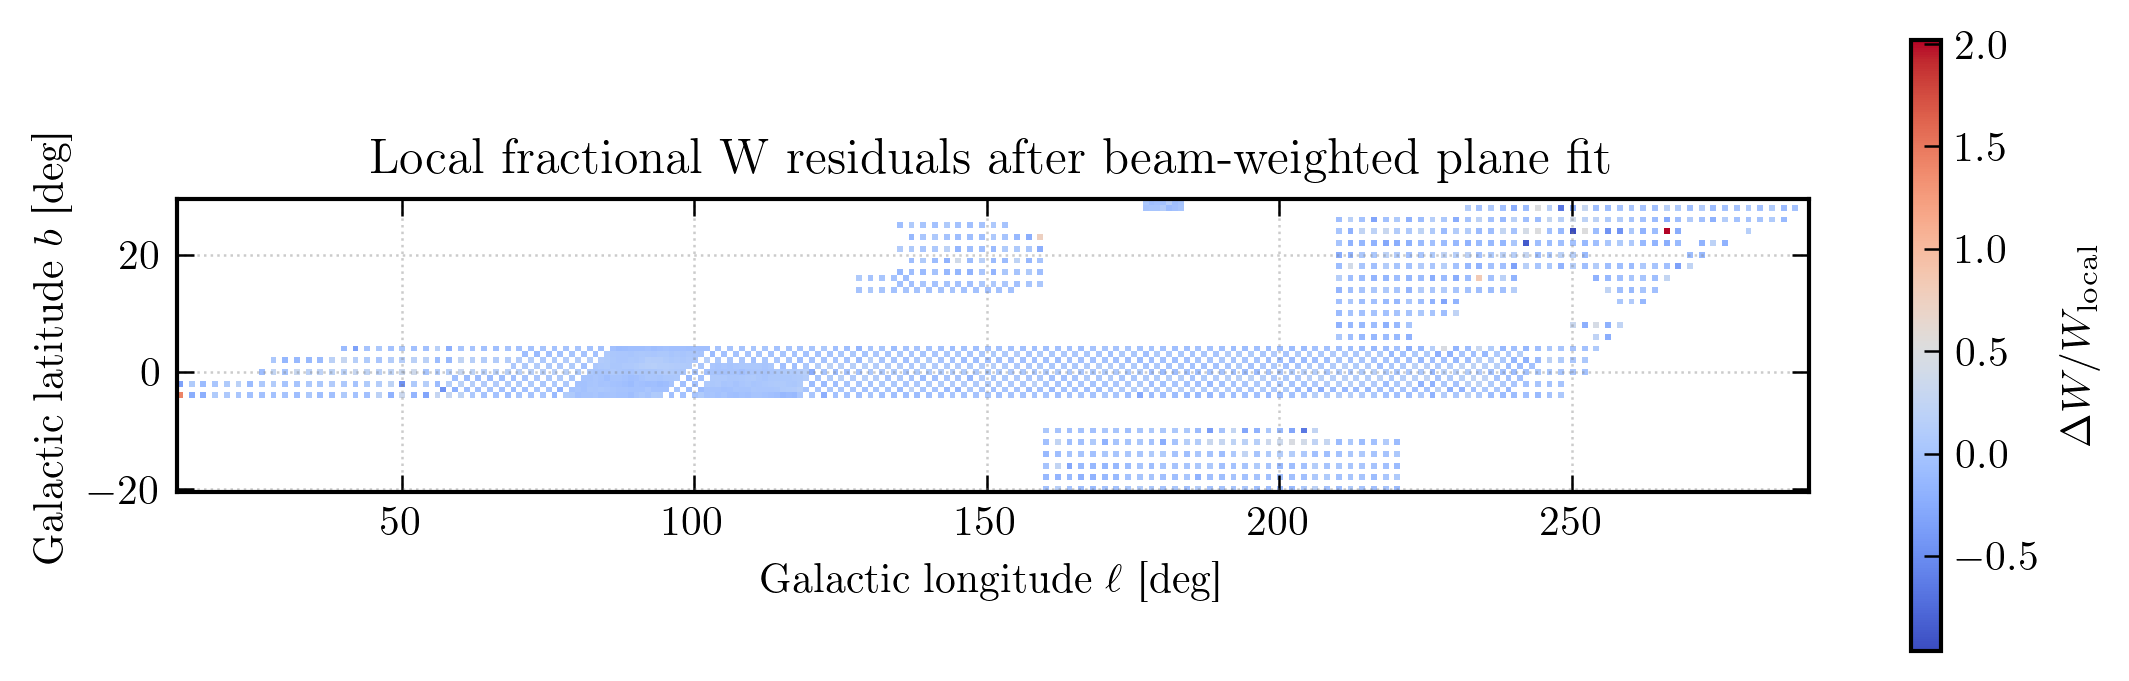

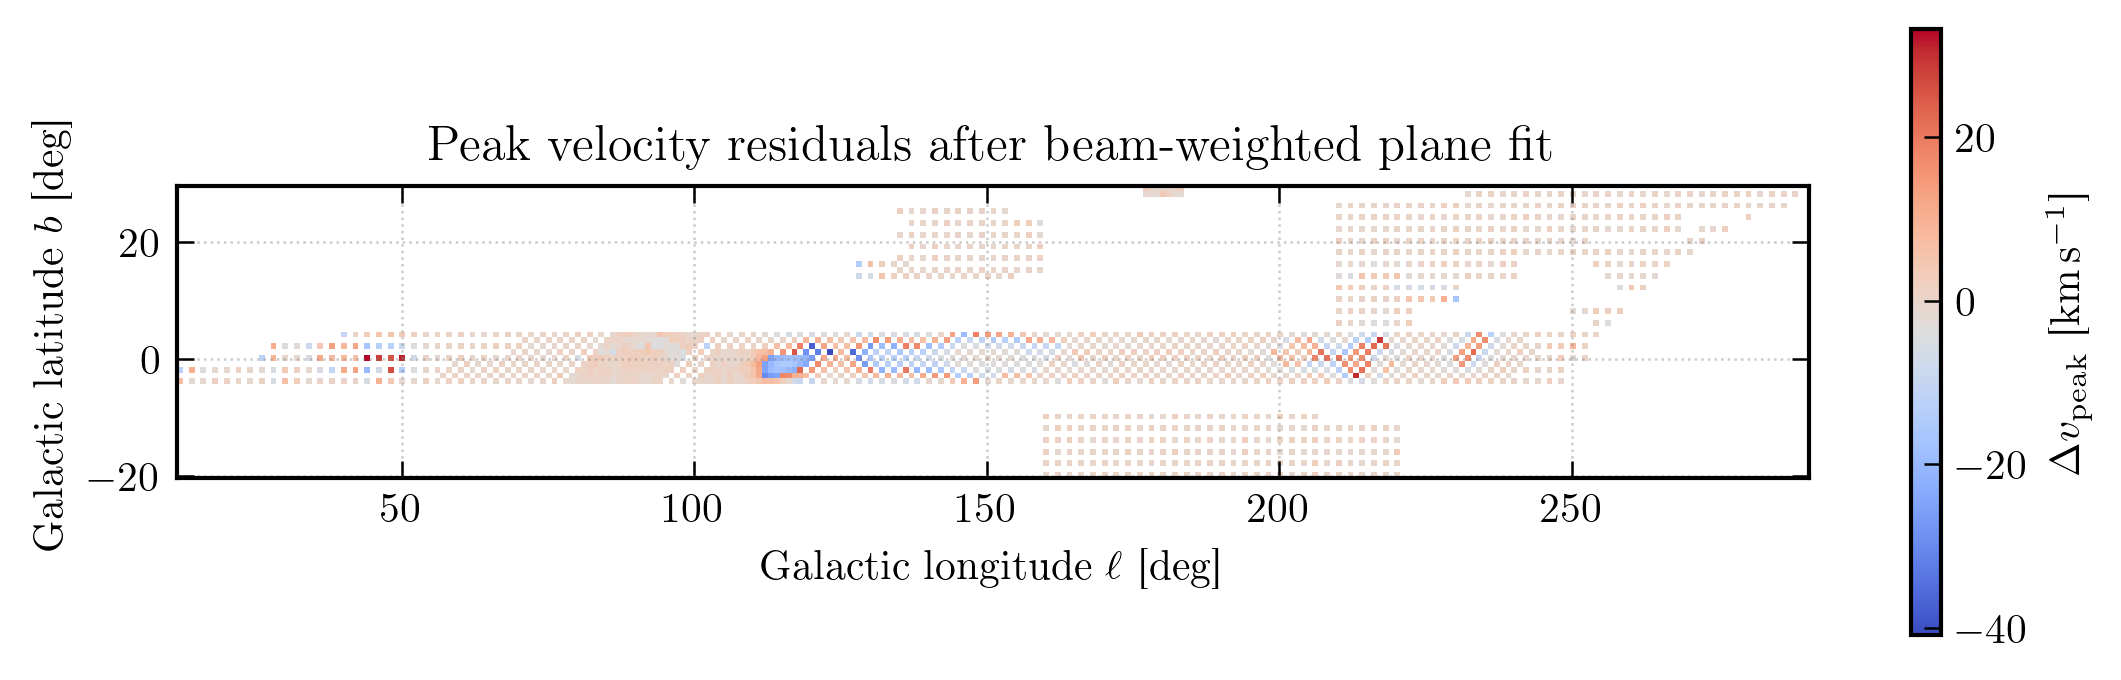

Flagged cells (21):
  l= 12 b= -4 n=5 W frac=+1.42 z=+6.43
  l= 12 b= -2 n=5 W frac=-0.33 z=-5.52
  l= 52 b= +0 n=20 W frac=+0.36 z=+4.46
  l= 57 b= -3 n=16 W frac=-0.46 z=-3.82
  l=115 b= -1 n=54 v dv=-15.3 z=-5.09
  l=123 b= +1 n=34 v dv=-40.9 z=-4.21
  l=145 b=+19 n=20 W frac=+0.39 z=+6.38
  l=159 b=+23 n=7 W frac=+0.75 z=+32.56
  l=208 b= +0 n=36 v dv=+20.5 z=+5.78
  l=212 b=+18 n=17 W frac=+0.40 z=+5.78
  l=228 b=+12 n=15 W frac=-0.30 z=-4.41
  l=234 b=+16 n=17 W frac=+0.82 z=+15.27
  l=242 b=+22 n=20 W frac=-0.87 z=-5.68
  l=248 b=+28 n=12 W frac=-0.67 z=-3.51
  l=250 b= +8 n=6 W frac=+0.32 z=+55.62
  l=250 b=+24 n=20 W frac=-0.96 z=-4.70
  l=254 b= +8 n=8 W frac=+0.44 z=+4.42
  l=256 b=+24 n=17 W frac=-0.45 z=-3.51
  l=258 b=+24 n=17 W frac=-0.45 z=-5.27
  l=266 b=+24 n=15 W frac=+2.02 z=+26.49
  l=268 b=+18 n=9 W frac=-0.34 z=-4.23


In [9]:
fig, ax = plot_heatmap(
    gl, gb, W_frac_resid,
    cbar_label=r"$\Delta W / W_{\mathrm{local}}$",
    cmap="coolwarm",
    title="Local fractional W residuals after beam-weighted plane fit",
)
plt.show()

fig, ax = plot_heatmap(
    gl, gb, peak_v_resid,
    cbar_label=r"$\Delta v_{\mathrm{peak}}$ [km\,s$^{-1}$]",
    cmap="coolwarm",
    title="Peak velocity residuals after beam-weighted plane fit",
)
plt.show()

# List flagged cells
if any_flag.any():
    print(f'Flagged cells ({any_flag.sum()}):')
    for i in np.where(any_flag)[0]:
        flags = []
        if W_flag[i]:
            flags.append(f'W frac={W_frac_resid[i]:+.2f} z={W_z[i]:+.2f}')
        if peak_v_flag[i]:
            flags.append(f'v dv={peak_v_resid[i]:+.1f} z={peak_v_z[i]:+.2f}')
        print(f'  l={cell_keys[i,0]:3d} b={cell_keys[i,1]:+3d} '
              f'n={int(neighbor_count[i])} {"; ".join(flags)}')

## 3. Pointing summary

In [10]:
import pandas as pd

rows_df = []
for i in range(len(cell_keys)):
    rows_df.append({
        'l': cell_keys[i, 0], 'b': cell_keys[i, 1],
        'n_pairs': int(n_pairs[i]),
        'n_1420': int(n_1420[i]),
        'n_1421': int(n_1421[i]),
        'W': W[i],
        'SNR': snr[i],
        'W_flag': bool(W_flag[i]),
        'v_flag': bool(peak_v_flag[i]),
    })

df = pd.DataFrame(rows_df).set_index(['l', 'b'])

print(f'Unique pointings: {len(df)}')
print(f'Total dumps: {df["n_1420"].sum() + df["n_1421"].sum()}')
print(f'Flagged: {any_flag.sum()} ({W_flag.sum()} W, {peak_v_flag.sum()} peak_v)')
print(f'Median SNR: {np.nanmedian(snr):.1f}')
print()
df

Unique pointings: 1618
Total dumps: 13596
Flagged: 21 (18 W, 3 peak_v)
Median SNR: 78.3



n_pairs  n_1420  n_1421          W        SNR  W_flag  v_flag
l   b                                                                 
12  -4         4       4       4  14.167903        NaN    True   False
    -2         4       4       4  16.232864        NaN    True   False
14  -4         4       4       4   9.497922        NaN   False   False
    -2         4       4       4  21.436695        NaN   False   False
16  -4         4       4       4  10.060938        NaN   False   False
...          ...     ...     ...        ...        ...     ...     ...
284  28        4       4       4   6.343597  58.095865   False   False
286  26        4       4       4   5.969367  62.537820   False   False
     28        4       4       4   5.501734  79.542085   False   False
288  28        4       4       4   5.884580  65.037143   False   False
290  28        4       4       5   6.284648  36.959739   False   False

[1618 rows x 7 columns]

## 4. Survey coverage + observability

Mollweide projection showing survey pointings colored by dump count,
overlaid with the never-observable region.

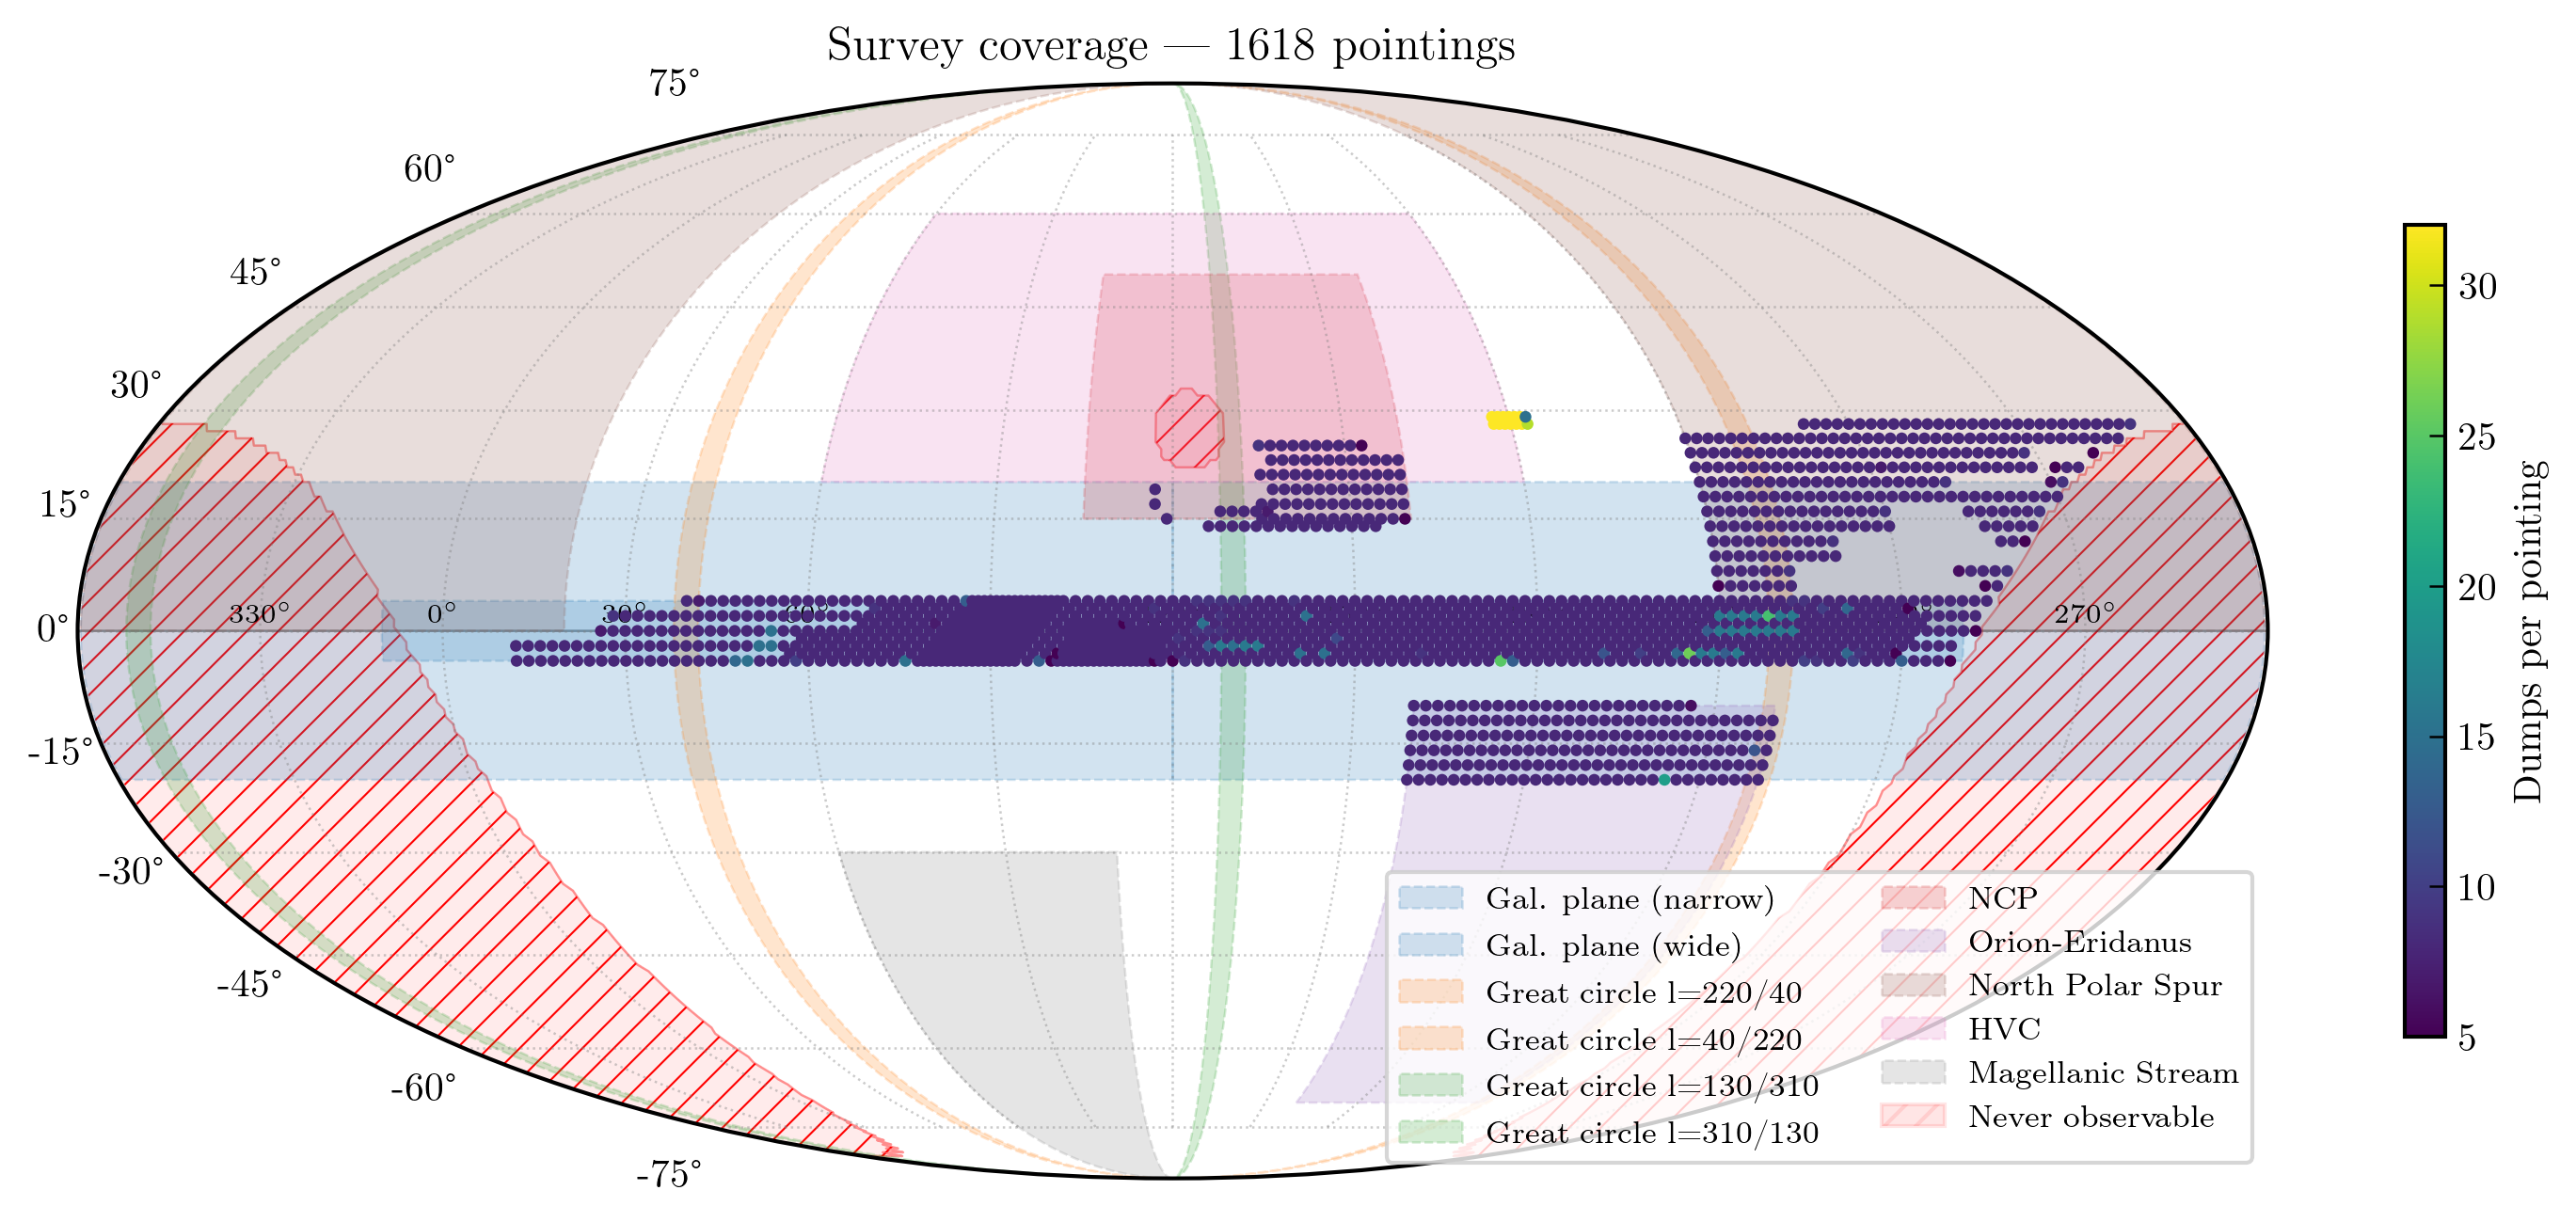

In [11]:
MOLL_CENTER_L = 120.0

n_dumps = n_1420 + n_1421
fig, ax = plot_survey_mollweide(
    gl, gb, n_dumps.astype(float),
    center_l=MOLL_CENTER_L,
    cbar_label="Dumps per pointing",
    cmap="viridis",
    marker_size=SS_FINE,
    title=f'Survey coverage --- {len(cell_keys)} pointings',
)

# Overlay candidate survey footprints
add_survey_footprints(ax, center_l=MOLL_CENTER_L)

# Legend: survey regions + never-observable
handles, labels = ax.get_legend_handles_labels()
handles.append(Rectangle((0, 0), 1, 1, facecolor='red', alpha=0.1,
                          edgecolor='red', hatch='///'))
labels.append('Never observable')
ax.legend(handles, labels, fontsize=LEGEND_SIZE - 1,
          loc='lower right', ncol=2)
plt.show()

## 5. Update survey manifest

Write per-pointing completeness to `survey_manifest.json` from the
reduced data.  QA-flagged cells are excluded so the observation script
will re-observe them.

In [12]:
from manifest import write_manifest, read_manifest

# Build manifest from reduced data, excluding QA-flagged cells
flagged_set = set()
for i in np.where(any_flag)[0]:
    flagged_set.add((int(cell_keys[i, 0]), int(cell_keys[i, 1])))

if flagged_set:
    print(f'Excluding {len(flagged_set)} QA-flagged cells from manifest')

manifest_pointings = {}
for i in range(len(cell_keys)):
    key = (int(cell_keys[i, 0]), int(cell_keys[i, 1]))
    if key in flagged_set:
        continue
    manifest_pointings[key] = {
        'n_1420': int(n_1420[i]),
        'n_1421': int(n_1421[i]),
    }

MANIFEST_PATH = Path('../survey_manifest.json')
write_manifest(manifest_pointings, MANIFEST_PATH)

pointings = read_manifest(MANIFEST_PATH)
incomplete = {lb: info for lb, info in pointings.items() if not info['complete']}
if incomplete:
    print(f'\nIncomplete cells ({len(incomplete)}):')
    print(f'  {"l":>4} {"b":>4} {"pairs":>5} {"target":>6} {"need":>5}')
    for (l, b), info in sorted(incomplete.items()):
        need = info['target'] - info['n_pairs']
        print(f'  {l:>4} {b:>+4} {info["n_pairs"]:>5} {info["target"]:>6} {need:>5}')
else:
    print('\nAll cells complete!')

Excluding 21 QA-flagged cells from manifest
Manifest written: ../survey_manifest.json
  1597 pointings: 1575 complete, 22 incomplete

Incomplete cells (22):
     l    b pairs target  need
    26   +0     3      4     1
    42   +4     3      4     1
    81   +1     3      4     1
   100   -4     2      4     2
   101   -3     2      4     2
   112   +1     2      4     2
   117   -4     2      4     2
   120   -4     2      4     2
   136  +16     3      4     1
   153  +25     2      4     2
   159  +15     2      4     2
   206  -10     3      4     1
   210   +6     2      4     2
   239   -3     2      4     2
   241   +3     2      4     2
   248   -4     2      4     2
   252   +0     2      4     2
   254   +6     2      4     2
   262  +12     2      4     2
   270  +20     3      4     1
   272  +22     2      4     2
   280  +24     2      4     2
